# EDA — Part B: Class Distribution & Imbalance Analysis

**Goal:** Quantify how the 7 emotions are distributed across the **training set**
and measure the imbalance. FER-2013 is famously skewed — *Disgust* is a tiny
minority, *Happy* is the majority.

**Why this matters (CONTRIBUTING.md §8):**
- A classifier trained on imbalanced data is biased toward majority classes —
  it can reach deceptively high **accuracy** by rarely predicting rare classes.
- This is why we will report **macro-F1** and **per-class recall**, not accuracy alone.
- The remedy is an ablation switch: `config.yaml → cleaning.imbalance_strategy`
  (`none | class_weight | oversample | undersample`), chosen in issue #18.

We analyse the **Training** split specifically, because that is the distribution
the model actually learns from — and therefore the distribution that biases it.

## 0. Setup

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path().resolve().parent  # notebooks/ → project root
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.emotion_detector.utils.config import load_config
from src.emotion_detector.utils.logging import setup_logging
from src.emotion_detector.data.fer2013 import Fer2013Fetcher

cfg = load_config(ROOT / "config.yaml")

# Resolve relative config paths to absolute (CWD is notebooks/ when running here).
for key in cfg["paths"]:
    cfg["paths"][key] = str(ROOT / cfg["paths"][key])

setup_logging(cfg)

# Where to save figures for data.md §2
EDA_DIR = Path(cfg["paths"]["results_dir"]) / "eda"
EDA_DIR.mkdir(parents=True, exist_ok=True)

EMOTION_LABELS = {
    0: "Angry", 1: "Disgust", 2: "Fear",
    3: "Happy", 4: "Sad",     5: "Surprise", 6: "Neutral",
}

sns.set_theme(style="whitegrid")
print(f"Figures will be saved to: {EDA_DIR}")

2026-07-04 13:27:00 | INFO     | src.emotion_detector.utils.logging:61 — Logging initialised — level=INFO, log_dir=/Users/mohammad.kheirkhah/Desktop/emotions-detecto/logs


Figures will be saved to: /Users/mohammad.kheirkhah/Desktop/emotions-detecto/results/eda


## 1. Load the training labels

We use `Fer2013Fetcher` — the same loader the training pipeline uses — so the
distribution we analyse is exactly what the model will see.

In [8]:
fetcher = Fer2013Fetcher(cfg)
_, labels_train = fetcher.fetch("Training")

# Wrap in a named Series so we get pandas' value_counts / map for free.
emotion = pd.Series(labels_train, name="emotion")
print(f"Training labels: {len(emotion):,}")
emotion.head()

2026-07-04 13:27:02 | INFO     | src.emotion_detector.data.fer2013:89 — Loading split 'Training': 28,709 rows from icml_face_data.csv
2026-07-04 13:27:04 | INFO     | src.emotion_detector.data.fer2013:104 — Split 'Training' ready — images (28709, 48, 48) uint8, labels (28709,)


Training labels: 28,709


0    0
1    0
2    2
3    4
4    6
Name: emotion, dtype: int64

## 2. Per-class counts and percentages

`value_counts()` gives raw counts; `value_counts(normalize=True)` gives
proportions (fractions that sum to 1.0). We map the integer codes to names
so the table is readable.

In [9]:
counts_s = emotion.value_counts().sort_index()
pct_s    = emotion.value_counts(normalize=True).sort_index() * 100

dist = pd.DataFrame({
    "emotion": counts_s.index.map(EMOTION_LABELS),
    "count":   counts_s.values,
    "percent": pct_s.round(2).values,
}, index=counts_s.index)
dist.index.name = "code"
dist

,emotion,count,percent
code,,,
0,Angry,3995,13.92
1,Disgust,436,1.52
2,Fear,4097,14.27
3,Happy,7215,25.13
4,Sad,4830,16.82
5,Surprise,3171,11.05
6,Neutral,4965,17.29


In [10]:
# Same table, sorted from most to least frequent — makes the long tail obvious.
dist_sorted = dist.sort_values("count", ascending=False)
print("Classes ordered by frequency (long tail → Disgust):")
dist_sorted

Classes ordered by frequency (long tail → Disgust):


,emotion,count,percent
code,,,
3,Happy,7215,25.13
6,Neutral,4965,17.29
4,Sad,4830,16.82
2,Fear,4097,14.27
0,Angry,3995,13.92
5,Surprise,3171,11.05
1,Disgust,436,1.52


## 3. Imbalance ratio

The **imbalance ratio** = (largest class count) / (smallest class count).
A ratio of 1.0 is perfectly balanced; higher means more skew. For reference,
a ratio above ~10 is considered strongly imbalanced.

In [11]:
majority_code = counts_s.idxmax()
minority_code = counts_s.idxmin()
imbalance_ratio = counts_s.max() / counts_s.min()

print(f"Majority class : {EMOTION_LABELS[majority_code]:<9} {counts_s.max():>6,} images ({pct_s[majority_code]:.1f}%)")
print(f"Minority class : {EMOTION_LABELS[minority_code]:<9} {counts_s.min():>6,} images ({pct_s[minority_code]:.1f}%)")
print(f"Imbalance ratio: {imbalance_ratio:.1f}x")
print()

# Naive baseline: always predict the majority class.
naive_acc = pct_s[majority_code]
print(f"Naive 'always predict {EMOTION_LABELS[majority_code]}' accuracy ≈ {naive_acc:.1f}%")
print("→ Any model must beat this to be doing real work; accuracy alone is misleading.")

Majority class : Happy      7,215 images (25.1%)
Minority class : Disgust      436 images (1.5%)
Imbalance ratio: 16.5x

Naive 'always predict Happy' accuracy ≈ 25.1%
→ Any model must beat this to be doing real work; accuracy alone is misleading.


## 4. Bar plots — counts and proportions

Two views of the same data, ordered most→least frequent:
- **Left:** absolute counts (how many training images per class).
- **Right:** proportions (each class as a % of the training set).

Saved: /Users/mohammad.kheirkhah/Desktop/emotions-detecto/results/eda/class_distribution_train.png


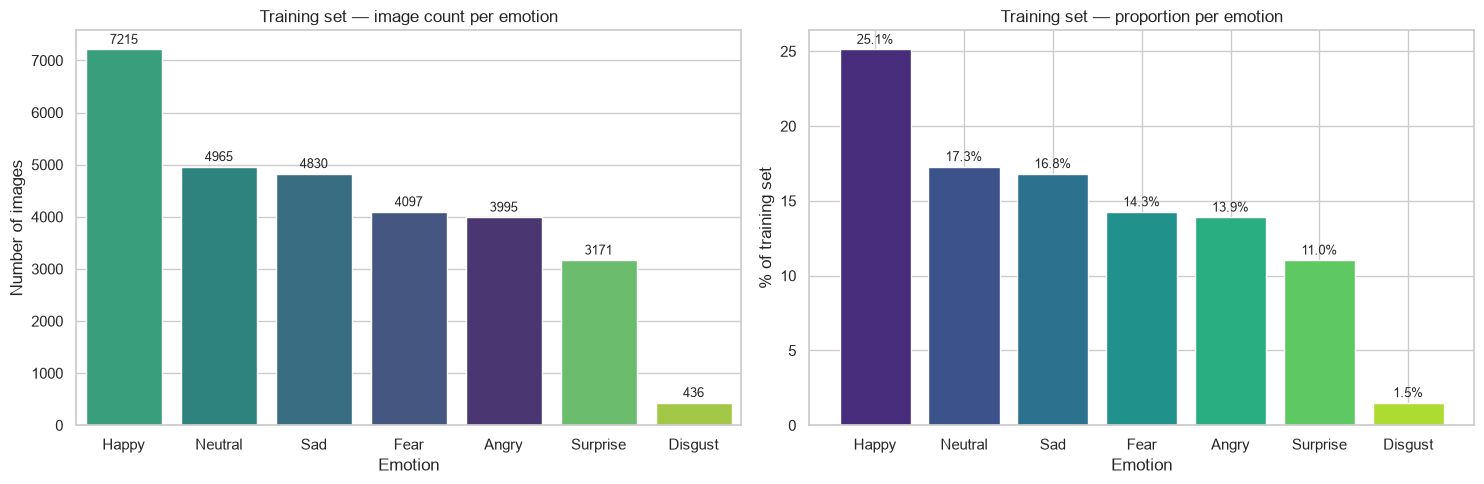

In [12]:
order_codes = list(dist_sorted.index)
order_names = [EMOTION_LABELS[c] for c in order_codes]
emotion_named = emotion.map(EMOTION_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: counts via seaborn countplot (aggregates the categorical column itself).
sns.countplot(
    x=emotion_named, order=order_names,
    hue=emotion_named, legend=False, palette="viridis", ax=axes[0],
)
axes[0].set_title("Training set — image count per emotion")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Number of images")
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d", padding=2, fontsize=9)

# Right: percentages via matplotlib bar.
pct_ordered = [pct_s[c] for c in order_codes]
bars = axes[1].bar(order_names, pct_ordered, color=sns.color_palette("viridis", len(order_names)))
axes[1].set_title("Training set — proportion per emotion")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("% of training set")
axes[1].bar_label(bars, fmt="%.1f%%", padding=2, fontsize=9)

plt.tight_layout()
fig_path = EDA_DIR / "class_distribution_train.png"
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
print(f"Saved: {fig_path}")
plt.show()

## 5. Findings for `data.md` §2

Numbers below are recorded into `data.md` §2 (EDA). They are the empirical
justification for the imbalance-handling decision in `config.yaml`.

| Emotion | Code | Train count | Train % |
|---|---|---|---|
| Happy | 3 | 7,215 | 25.1 % |
| Neutral | 6 | 4,965 | 17.3 % |
| Sad | 4 | 4,830 | 16.8 % |
| Fear | 2 | 4,097 | 14.3 % |
| Angry | 0 | 3,995 | 13.9 % |
| Surprise | 5 | 3,171 | 11.0 % |
| Disgust | 1 | 436 | 1.5 % |
| **Total** | — | **28,709** | **100 %** |

- **Imbalance ratio ≈ 16.5×** (Happy 7,215 / Disgust 436 on the Training split).
- **Naive majority-class accuracy ≈ 25 %** — the floor any real model must clear.
- The imbalance is **consistent across all three splits** (see `01_eda.ipynb` §10),
  so validation/test metrics are measured on the same skew.

**Implications for training (learning-loop discussion):**
- Without correction, gradient updates are dominated by Happy/Neutral/Sad; the
  model under-learns Disgust and Surprise.
- Remedy is a `config.yaml` ablation (`cleaning.imbalance_strategy`): `class_weight`
  (inverse-frequency penalty), `oversample`, or `undersample` — compared in #18.
- Evaluation must use **macro-F1** (equal weight per class) and **per-class recall**,
  not accuracy — already listed in `config.yaml → evaluation.metrics`.

> Note: exact per-split counts come from the Training split via `Fer2013Fetcher`.
> If you re-run, refresh the table above from the §2 output.